In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, Markdown

In [2]:
import librosa # audio and music analysis and manipulation
import soundfile as sf # read and write sound files

#### Load Audio

In [3]:
file_path = '../data/speech_01.wav'
Audio(file_path)

In [4]:
audio_signal, sample_rate = librosa.load(file_path, sr = None) # sr = None, ensure the audio is loaded at its original sample rate

#### Display Audio Waveform

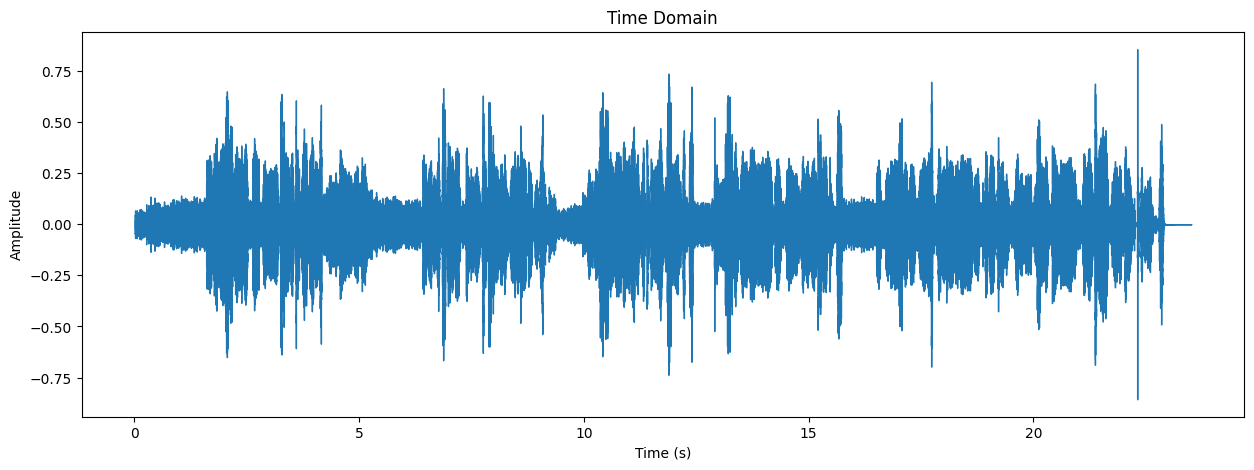

In [5]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(audio_signal, sr = sample_rate)
plt.title('Time Domain')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

75% is the max amplitude an audio can reach without clipping or distortion

#### Short-time Fourier Transform

In [6]:
S = librosa.stft(audio_signal) # stft calculates the freq components of the audio signal and stores them in the variable 'S'

'S' is matrix with complex numbers containing 2 parts: Amplitude & Phase

In [7]:
S_db = librosa.amplitude_to_db(abs(S), ref = np.max) # amplitude_to_db function converts the amplitudes to match the way humans hear sound

abs(S) removes phase component of the complex number and gives us amplitude of each freq

np.max sets the max amplitude to 0 db as reference

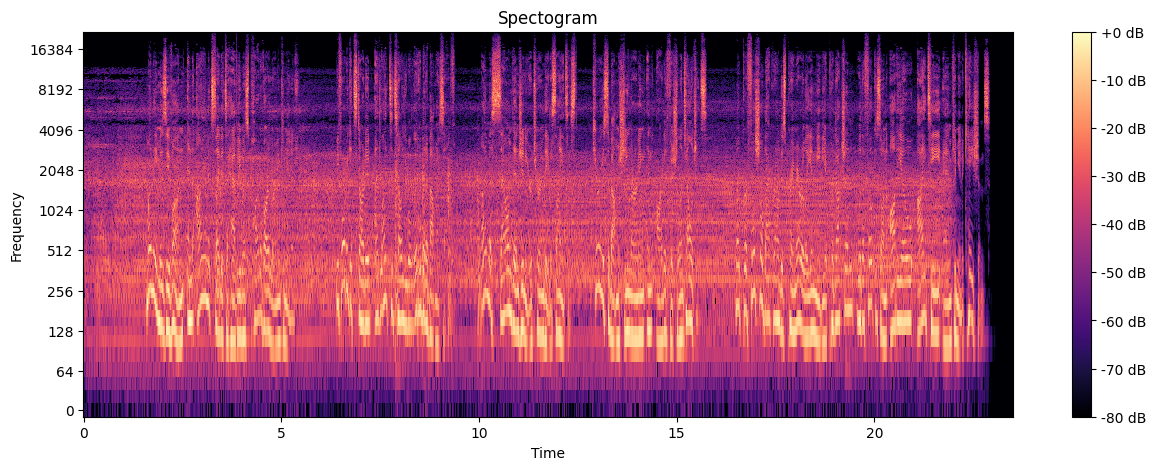

In [8]:
plt.figure(figsize=(15, 5))
librosa.display.specshow(data = S_db, sr = sample_rate, x_axis = 'time', y_axis = 'log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

A spectogram contains Amplitude, Frequency and Time information in one graph

Fundamental Frequency of human speech typically falls between 80 and 250 Hz while higher frequencies often help distinguish consonants

#### Filter Signal

> Pre-emphasis is one of the many ways to remove background noise

In [9]:
signal_filtered = librosa.effects.preemphasis(audio_signal, coef=0.7) # emphasize high frequencies for clarity in speech

In [10]:
output_file_path = '../data/filtered_speech_01.wav'
sf.write(output_file_path, signal_filtered, sample_rate)

In [11]:
Audio(output_file_path)

In [12]:
Sb = librosa.stft(signal_filtered)

In [13]:
Sb_db = librosa.amplitude_to_db(abs(Sb), ref = np.max)

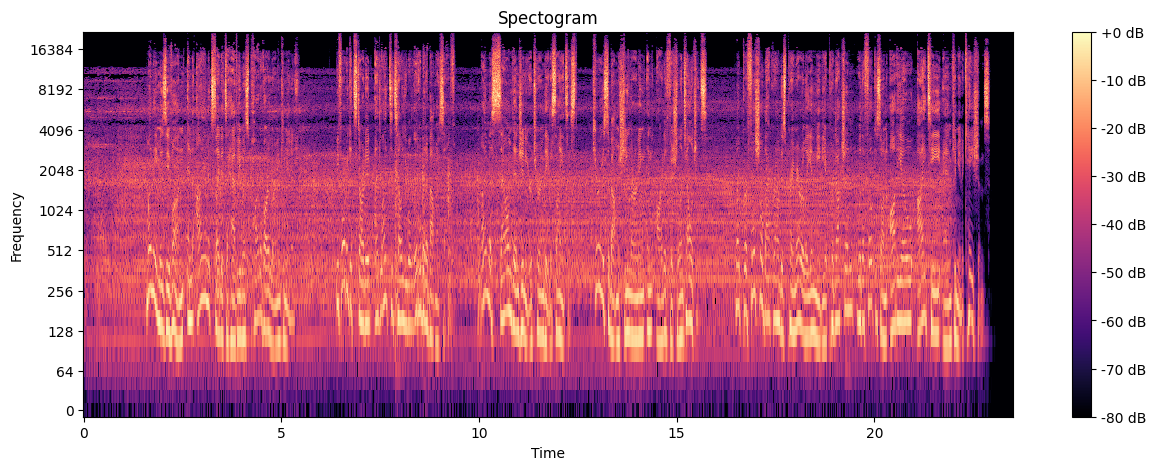

In [14]:
plt.figure(figsize=(15, 5))
librosa.display.specshow(data = Sb_db, sr = sample_rate, x_axis = 'time', y_axis = 'log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

#### Speech --> Text

In [15]:
import speech_recognition as sr # spoken language into written text

In [16]:
recognizer = sr.Recognizer() # recognize speech from various sources (microphone, audio file, etc.)

In [17]:
def transcribe_audio(file_path):
    with sr.AudioFile(file_path) as source:
        audio_data = recognizer.record(source) # record() captures audio data from the source
        text = recognizer.recognize_whisper(audio_data, model = 'base')

    return text

In [18]:
output_text = transcribe_audio(output_file_path)

In [19]:
Markdown(display(output_text))

" My name is Yvonne and I am excited to have you as part of our learning community. Before we get started, I'd like to tell you a little bit about myself. I'm a sound engineer turned a scientist, curious about machine learning and artificial intelligence. My professional background is primarily in media production, with a focus on audio, IT, and communications."

<IPython.core.display.Markdown object>

#### Evaluate

WER and CER check for substitutions, insertions and deletions

> WER is also affected by capitals

> CER is also affected by punctuations and capitals

In [20]:
from jiwer import wer, cer

In [21]:
ground_truth = """My name is Ivan and I am excited to have you as part of our learning community! 
Before we get started, I'd like to tell you a little bit about myself. I'm a sound engineer turned data scientist,
curious about machine learning and Artificial Intelligence. My professional background is primarily in media production,
with a focus on audio, IT, and communications"""

In [22]:
display(Markdown(output_text))

 My name is Yvonne and I am excited to have you as part of our learning community. Before we get started, I'd like to tell you a little bit about myself. I'm a sound engineer turned a scientist, curious about machine learning and artificial intelligence. My professional background is primarily in media production, with a focus on audio, IT, and communications.

In [23]:
wer(ground_truth, output_text)

0.1694915254237288

In [24]:
cer(ground_truth, output_text)

0.03867403314917127